In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import gsw

# --- Constants for O2 solubility (Garcia & Gordon fit to Benson & Krause) ---
A0_o2 = 5.80871
A1_o2 = 3.20291
A2_o2 = 4.17887
A3_o2 = 5.10006
A4_o2 = -9.86643e-2
A5_o2 = 3.80369
B0_o2 = -7.01577e-3
B1_o2 = -7.70028e-3
B2_o2 = -1.13864e-2
B3_o2 = -9.51519e-3
C0_o2 = -2.75915e-7

CNV_FILL_VALUES = {-9.990e-29, -9.999e-29, -9.990e-15, -9.999e-15}

def parse_cnv_header(file_path, encoding="ISO-8859-1"):
    import re
    header_dict = {}
    name_map = {}
    end_idx = None
    with open(file_path, 'r', encoding=encoding, errors="ignore") as f:
        for i, line in enumerate(f):
            s = line.strip().rstrip("\r")
            if s.startswith('#'):
                m = re.match(r'#\s*([^=]+)=(.*)', s)
                if m:
                    header_dict[m.group(1).strip()] = m.group(2).strip()
                n = re.match(r'#\s*name\s+(\d+)\s*=\s*([^:]+)', s, flags=re.IGNORECASE)
                if n:
                    idx = int(n.group(1))
                    raw = n.group(2).strip()
                    col = re.sub(r'\s+', '_', raw)
                    name_map[idx] = col
            if re.search(r'\*END\*', s, flags=re.IGNORECASE):
                end_idx = i
                break
    if end_idx is None:
        raise ValueError(f"Could not find '*END*' in header: {file_path}")
    colnames = [name_map[k] for k in sorted(name_map)] if name_map else None
    return end_idx + 1, colnames, header_dict


def read_cnv(file_path, encoding="ISO-8859-1"):
    skiprows, colnames, header = parse_cnv_header(file_path, encoding=encoding)
    df = pd.read_csv(
        file_path,
        sep=r'\s+',
        engine="python",
        header=None if colnames is not None else 'infer',
        names=colnames,
        skiprows=skiprows,
        encoding=encoding,
        na_values=list(CNV_FILL_VALUES) + ["nan", "NaN", "NAN"]
    )
    # Drop completely empty rows that sometimes appear at the end
    df = df.dropna(how="all")
    return df, header

def extract_cast_id_from_stem(stem):
    # Example stems like: XXX_123_postcal_filter_CTM_loop_derive_8s_d1dbar
    parts = stem.split("_")
    # try to grab the first numeric token
    for p in parts:
        if p.isdigit():
            return int(p)
        # also try mixed digits, e.g. "cast123"
        m = re.search(r'(\d+)', p)
        if m:
            return int(m.group(1))
    return None

from pathlib import Path

def load_leg(path_like, pattern="*postcal_filter_CTM_loop_derive_7s_d1dbar.cnv"):
    p = Path(path_like)
    if p.is_dir():
        files = sorted(p.glob(pattern))
    else:
        files = sorted(p.parent.glob(p.name))

    # Skip AppleDouble and hidden files, non-files, and zero-byte files
    clean_files = [
        f for f in files
        if f.is_file()
        and not f.name.startswith("._")
        and not f.name.startswith(".")
        and f.suffix.lower() == ".cnv"
        and f.stat().st_size > 0
    ]
    if not clean_files:
        raise FileNotFoundError(f"No CNV files found for {p} (pattern='{pattern}').")

    frames = []
    for file in clean_files:
        df, hdr = read_cnv(file)
        cast_id = extract_cast_id_from_stem(file.stem)
        if cast_id is None:
            print(f"[warn] Couldn't parse cast id from {file.name}")
        frames.append(df.assign(cast=cast_id, _source=file.name))
    return pd.concat(frames, ignore_index=True)


# --- LOAD BOTH LEGS (dynamic header parsing; no hardcoded skiprows) ---
postnorth_df = load_leg("/Users/mariacristinaalvarez/Documents/Github/ArcticO2/HLY2022_data/Align7s/Northbound")
postsouth_df = load_leg("/Users/mariacristinaalvarez/Documents/Github/ArcticO2/HLY2022_data/Align7s/Southbound")

#postnorth_df = load_leg(north_glob)
#postsouth_df = load_leg(south_glob)
# --- PRE CTD FILES (Northbound) ---
pre_north_path = Path("/Users/mariacristinaalvarez/Documents/Github/ArcticO2/HLY2022_data/CTD_Northbound")

# Use the same loader, but with a different pattern
prenorth_raw = load_leg(pre_north_path, pattern="*Pre1dbar.cnv")

# Ensure both have a 'cast' column (your previous code used 'filename' for south; fix that)
assert 'cast' in postnorth_df.columns
assert 'cast' in postsouth_df.columns

# --- Harmonize essential columns ---
# Guess common names from Sea-Bird; adjust these strings if your headers differ:
# Common Sea-Bird column keys to map to simpler names
col_aliases = {
    # pressure
    'prDM': 'pressure', 'Pressure': 'pressure',
    # depth
    'depSM': 'depth', 'Depth': 'depth',
    # latitude/longitude (decimal degrees if available)
    'latitude': 'latitude', 'Latitude': 'latitude', 'lat': 'latitude',
    'longitude': 'longitude', 'Longitude': 'longitude', 'lon': 'longitude',
    # salinity & temperature (practical salinity, in situ temperature ITS-90)
    'sal00': 'salinity', 'Salinity': 'salinity', 'Sal00': 'salinity', 'sal': 'salinity',
    't090C': 'temperature', 'Temperature': 'temperature', 't68': 'temperature', 't090': 'temperature',
    # oxygen (umol/kg) if present from derived channels; otherwise you may only have sensor counts
    'oxygen': 'oxygen', 'Oxygen': 'oxygen', 'oxyg_umol/kg': 'oxygen', 'Sbeox0ML/L': 'sbox0Mm/Kg'
}
import re

def is_secondary_sensor(raw_name: str) -> bool:
    """
    Return True for common Sea-Bird second-sensor channel names.
    Examples: t190C (temp #2), Sal11 (sal #2), SBEox1..., c1S/m (cond #2), etc.
    """
    s = str(raw_name).strip().lower()
    secondary_patterns = [
        r'^t1', r'^t19', r't190c',            # temperature secondary
        r'^sal1', r'sal11',                   # salinity secondary
        r'sbeox1', r'ox.*1ml', r'oxygen.*1',  # oxygen secondary (if present)
        r'^c1', r'cond1', r'conductivity1',   # conductivity secondary
        r'^fl1', r'fluor1',                   # fluorescence secondary (if present)
    ]
    return any(re.search(p, s) for p in secondary_patterns)

def normalize_columns(df):
    rename_map = {}
    keep_cols = []

    # --- always keep metadata if present ---
    for meta in ['cast', '_source']:
        if meta in df.columns:
            keep_cols.append(meta)  # keep as-is

    for c in df.columns:
        if c in ('cast', '_source'):   # already handled
            continue

        base = re.sub(r'[\[\(].*?[\]\)]', '', str(c)).replace(':', '').strip()
        if is_secondary_sensor(base):
            continue  # drop second sensor

        low = base.lower()

        # PRESSURE / DEPTH
        if 'prdm' in low or 'press' in low or low == 'pressure':
            rename_map[c] = 'pressure'; keep_cols.append(c); continue
        if low.startswith('dep') or low == 'depth':
            rename_map[c] = 'depth'; keep_cols.append(c); continue

        # LAT / LON
        if low in ('lat', 'latitude'):
            rename_map[c] = 'latitude'; keep_cols.append(c); continue
        if low in ('lon', 'longitude'):
            rename_map[c] = 'longitude'; keep_cols.append(c); continue

        # SALINITY (primary)
        if (low.startswith('sal00') or low.startswith('sal0') or
            low == 'salinity' or 'salinity' in low):
            rename_map[c] = 'salinity'; keep_cols.append(c); continue

        # TEMPERATURE (primary)
        if low.startswith('t090') or low.startswith('t09') or low == 'temperature' or 'temperature' in low:
            rename_map[c] = 'temperature'; keep_cols.append(c); continue

        # OXYGEN (already µmol/kg in your case)
        # OXYGEN (already µmol/kg in your case)
        if ('umol/kg' in low or 'umolkg' in low or low.endswith('_umolkg') or
             'oxyg_umol' in low or low == 'oxygen' or
             'sbeox0mm/kg' in low or 'sbox0mm/kg' in low):
             rename_map[c] = 'oxygen'; keep_cols.append(c); continue


        # else: ignore column

    out = df.loc[:, keep_cols].rename(columns=rename_map)

    # Safety: if any canonical name still duplicated (rare), collapse to first non-null
    if out.columns.duplicated().any():
        out = out.groupby(level=0, axis=1).first()

    return out


postnorth_df = normalize_columns(postnorth_df)
postsouth_df = normalize_columns(postsouth_df)
prenorth_df = normalize_columns(prenorth_raw)

print("North files read:", postnorth_df["_source"].nunique())
print("South files read:", postsouth_df["_source"].nunique())
print("Pre-north files read:", prenorth_df["_source"].nunique())
# If you still hit an error, list what got picked:
# for f in sorted(Path("/Volumes/EXTERNAL HA/HLY2202_CTD 2/Align8s/Northbound").glob("*")):
#     print(f.name)

# Combine and keep only rows with a parsed cast and essential physical vars
#all_df = pd.concat([postnorth_df, postsouth_df], ignore_index=True)
# Combine everything
all_df = pd.concat(
    [
        prenorth_df,
        postnorth_df,
        postsouth_df,
    ],
    ignore_index=True
)
all_df = all_df.dropna(subset=['cast'])

# Try to coerce types
for col in ['pressure','depth','latitude','longitude','salinity','temperature','oxygen']:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

# Replace fill values with NaN if any slipped past
for fv in CNV_FILL_VALUES:
    all_df = all_df.replace(fv, np.nan)

# --- Compute seawater properties where possible ---
def calculate_seawater_properties(df):
    df = df.copy()
    # Only compute when required columns exist
    has_SP = {'salinity','pressure','longitude','latitude'}.issubset(df.columns)
    if has_SP:
        df['SA'] = gsw.SA_from_SP(df['salinity'].values, df['pressure'].values,
                                   df['longitude'].values, df['latitude'].values)
        # in-situ temperature to potential and then CT
        if 'temperature' in df.columns:
            df['theta'] = gsw.pt0_from_t(df['SA'].values, df['temperature'].values, df['pressure'].values)
            df['CT'] = gsw.CT_from_pt(df['SA'].values, df['theta'].values)
            # sigma0
            df['sigma0'] = gsw.sigma0(df['SA'].values, df['CT'].values)

    return df

all_df = calculate_seawater_properties(all_df)


def extract_cast_id_from_stem(stem: str):
    import re
    # Prefer a 2–4 digit token that immediately follows an underscore
    m = re.search(r'_(\d{2,4})(?:_|$)', stem)
    if m:
        n = int(m.group(1))
        # prefer likely cast range (not the year)
        if 1 <= n <= 999:
            return n
    # Fallback: any digits; pick the first that looks like a cast (<=999)
    nums = re.findall(r'\d+', stem)
    for n in nums:
        ni = int(n)
        if 1 <= ni <= 999:
            return ni
    return int(nums[0]) if nums else None
# Ensure _source is present (we preserved it in normalize_columns)
assert '_source' in all_df.columns, "Missing _source; ensure normalize_columns keeps it."

all_df['Cast'] = all_df['_source'].apply(extract_cast_id_from_stem).astype('Int64')

# Sensor-level correction factor (1 for most casts, 1.0075886344869687... for 0–8)
# CF = 1.0075886344869687 is the mean Winkler/CTD ratio for casts 0–8, computed from the CF_sensor1 code.
all_df["oxy_sensor_factor"] = 1.0
mask_first_sensor = (all_df["Cast"] >= 0) & (all_df["Cast"] <= 8)
all_df.loc[mask_first_sensor, "oxy_sensor_factor"] = 1.0075886344869687

# Apply sensor correction
all_df["oxygen_sensor_corr"] = all_df["oxygen"] * all_df["oxy_sensor_factor"]

# --- Winkler bottles (keep QC==2) and compute SA/CT/sigma0 there too ---
stations = pd.read_csv("/Users/mariacristinaalvarez/Documents/Github/ArcticO2/Processed_Winklerfiles/HLY2202_Winklerbottle.csv")
stations = stations.dropna(subset=['Winkler umol/kg'])
stations_df = stations.loc[stations['QC'] == 2].copy()

# Ensure consistent column names with your Winkler file
stations_df.rename(columns={
    'Sal00':'salinity',
    'PrDM':'pressure',
    'Longitude':'longitude',
    'Latitude':'latitude',
    'T090C':'temperature',
    'Winkler umol/kg':'oxygen_wink'
}, inplace=True)

# Compute seawater props for Winklers
stations_df['SA'] = gsw.SA_from_SP(stations_df['salinity'].values, stations_df['pressure'].values,
                                   stations_df['longitude'].values, stations_df['latitude'].values)
stations_df['theta'] = gsw.pt0_from_t(stations_df['SA'].values, stations_df['temperature'].values, stations_df['pressure'].values)
stations_df['CT'] = gsw.CT_from_pt(stations_df['SA'].values, stations_df['theta'].values)
stations_df['sigma0'] = gsw.sigma0(stations_df['SA'].values, stations_df['CT'].values)

# --- quick sanity checks ---
print(f"Northbound files: {postnorth_df['_source'].nunique() if '_source' in postnorth_df else 'n/a'}")
print(f"Southbound files: {postsouth_df['_source'].nunique() if '_source' in postsouth_df else 'n/a'}")
print("all_df shape:", all_df.shape)
print("stations_df shape:", stations_df.shape)
print("all_df columns:", list(all_df.columns)[:20])


North files read: 14
South files read: 30
Pre-north files read: 10
Northbound files: 14
Southbound files: 30
all_df shape: (43376, 16)
stations_df shape: (838, 35)
all_df columns: ['cast', '_source', 'pressure', 'depth', 'temperature', 'salinity', 'oxygen', 'latitude', 'longitude', 'SA', 'theta', 'CT', 'sigma0', 'Cast', 'oxy_sensor_factor', 'oxygen_sensor_corr']


In [ ]:
stations_df['']

In [44]:

# Make sure stations_df Cast is numeric too
stations_df['Cast'] = pd.to_numeric(stations_df.get('Cast', stations_df.get('cast')), errors='coerce').astype('Int64')

# ---- Restrict CF calculation to casts used in g1–g4 (e.g., 10–53) ----
cf_cast_min, cf_cast_max = 10, 53   # adjust if your block ranges differ

stations_df_cf = stations_df[
    (stations_df['Cast'] >= cf_cast_min) & (stations_df['Cast'] <= cf_cast_max)
].copy()

all_df_cf = all_df[
    (all_df['Cast'] >= cf_cast_min) & (all_df['Cast'] <= cf_cast_max)
].copy()


In [45]:
wink_0_10 = stations_df[
    stations_df["Cast"].between(0, 10, inclusive="both")
].copy()

n_wink_0_10 = wink_0_10["oxygen_wink"].notna().sum()
n_rows_0_10 = len(wink_0_10)

print("Winkler rows (casts 0–10):", n_rows_0_10)
print("Winkler O2 samples (non-NaN oxygen_wink) casts 0–10:", n_wink_0_10)
print("Unique casts present (0–10):", sorted(wink_0_10["Cast"].dropna().unique()))

Winkler rows (casts 0–10): 68
Winkler O2 samples (non-NaN oxygen_wink) casts 0–10: 68
Unique casts present (0–10): [0, 1, 3, 5, 6, 8]


In [46]:
import os
# importing St Laurents file for cross comparison
file_path = '/Users/mariacristinaalvarez/Documents/Github/ArcticO2/StLaurents_d2022-045-0022.cnv'
if os.path.exists(file_path):
    print("File is accessible.")
else:
    print("File not found.")

# Example encodings: "utf-8", "latin1", "ISO-8859-1"
try:
    compare = pd.read_csv(file_path, encoding="utf-8", sep=r'\s+', skiprows=569, header=None)
    print("File read successfully.")
except Exception as e:
    print(f"Error with encoding: {e}")

File is accessible.
File read successfully.


In [47]:
import numpy as np
import pandas as pd

wink_casts = set(stations_df_cf['Cast'].dropna().unique())
ctd_casts  = set(all_df_cf['Cast'].dropna().unique())
intersect  = sorted(wink_casts & ctd_casts)

print("Winkler casts (n):", len(wink_casts))
print("CTD casts (n):    ", len(ctd_casts))
print("Intersect (n):    ", len(intersect), "sample:", intersect[:10])

wink_cols = ['Cast', 'sigma0', 'oxygen_wink', 'pressure']
ctd_cols  = ['Cast', 'sigma0', 'oxygen', 'pressure']

stations_use = stations_df_cf[wink_cols].dropna(subset=['Cast', 'sigma0', 'oxygen_wink']).copy()
ctd_use      = all_df_cf[ctd_cols].dropna(subset=['Cast', 'sigma0', 'oxygen']).copy()

# minimal: normalize types for stable sorting / matching
stations_use["Cast"] = stations_use["Cast"].astype(str)
ctd_use["Cast"]      = ctd_use["Cast"].astype(str)
stations_use["sigma0"] = pd.to_numeric(stations_use["sigma0"], errors="coerce")
ctd_use["sigma0"]      = pd.to_numeric(ctd_use["sigma0"], errors="coerce")

stations_use = stations_use.dropna(subset=["sigma0"]).copy()
ctd_use      = ctd_use.dropna(subset=["sigma0"]).copy()

# minimal: rename CTD cols so merge cannot create duplicate column names
ctd_use = ctd_use.rename(columns={"oxygen": "oxygen_ctd", "pressure": "pressure_ctd"})
stations_use = stations_use.rename(columns={"pressure": "pressure_wink"})  # optional but clearer

# Sort within each cast (required by merge_asof in the loop)
stations_use = stations_use.sort_values(['Cast', 'sigma0']).reset_index(drop=True)
ctd_use      = ctd_use.sort_values(['Cast', 'sigma0']).reset_index(drop=True)

tol = 0.05  # try 0.02–0.05 kg m^-3

out = []
for cast, sgrp in stations_use.groupby('Cast', sort=True):
    cgrp = ctd_use[ctd_use['Cast'] == cast]
    if cgrp.empty:
        continue

    # IMPORTANT: ensure each group is sorted by sigma0
    sgrp = sgrp.sort_values("sigma0")
    cgrp = cgrp.sort_values("sigma0")

    m = pd.merge_asof(
        sgrp, cgrp,
        on='sigma0',
        direction='nearest',
        tolerance=tol,
        allow_exact_matches=True,
    )
    out.append(m)

if not out:
    raise ValueError("No per-cast matches. Check Cast overlap and sigma0 tolerance.")

matchall = pd.concat(out, ignore_index=True)

print("oxygen-like columns:", matchall.filter(like="oxygen").columns.tolist())

# CF = Winkler / CTD
matchall = matchall.dropna(subset=['oxygen_wink', 'oxygen_ctd'])
matchall['CF'] = matchall['oxygen_wink'] / matchall['oxygen_ctd']

print("Overall CF:", matchall['CF'].mean())


Winkler casts (n): 31
CTD casts (n):     44
Intersect (n):     31 sample: [11, 13, 14, 15, 17, 18, 19, 20, 21, 22]
oxygen-like columns: ['oxygen_wink', 'oxygen_ctd']
Overall CF: 1.0141777408612462


In [48]:
print("Total candidate rows (all Winkler samples carried through merge):", len(matchall))

n_matched = matchall["oxygen_ctd"].notna().sum()
print("Total successful matches (within sigma0 tolerance):", int(n_matched))

print("Total unmatched Winkler samples:", int(matchall["oxygen_ctd"].isna().sum()))

Total candidate rows (all Winkler samples carried through merge): 756
Total successful matches (within sigma0 tolerance): 756
Total unmatched Winkler samples: 0


Text(0.5, 0, 'Winkler O₂ (umol/kg)')

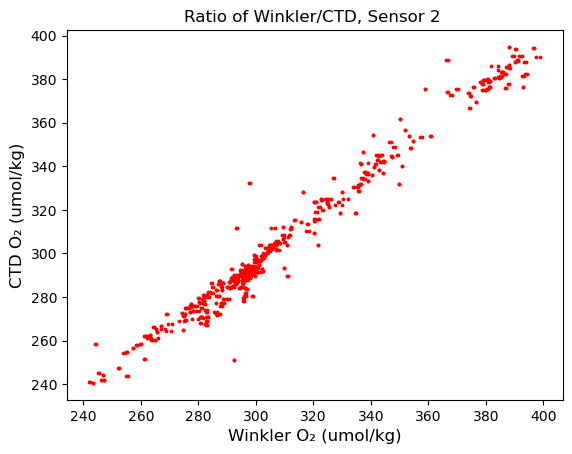

In [84]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(matchall['oxygen_wink'], matchall['oxygen_ctd'] ,c= 'red', s=3)
plt.title('Ratio of Winkler/CTD, Sensor 2 ')
plt.ylabel('CTD O₂ (umol/kg)',fontsize=12)
plt.xlabel('Winkler O₂ (umol/kg)' ,fontsize=12)

Base fit: oxygen_ctd = 14.914360 + 0.929589 * oxygen_wink
  100-500   dbar | n= 296 | exp_decay: A=+2.1181, B=-4.498e-03, C=-0.4802 (Pref=207)
  500-1000  dbar | n=  56 | exp_decay: A=+0.8169, B=-4.957e-03, C=-1.8888 (Pref=696)
 1000-2000  dbar | n=  44 | exp_decay: A=+17685.1942, B=-2.448e-07, C=-17688.3505 (Pref=1442)
 2000-3000  dbar | n=  31 | exp_decay: A=+4316.7119, B=-9.629e-07, C=-4323.3468 (Pref=2437)
 3000-4100  dbar | n=  14 | exp_decay: A=+3625.4301, B=-3.368e-07, C=-3635.0234 (Pref=3635)
Accuracy (STD of residuals, umol/kg): all=1.966 (n=441), >500dbar=1.602 (n=145)


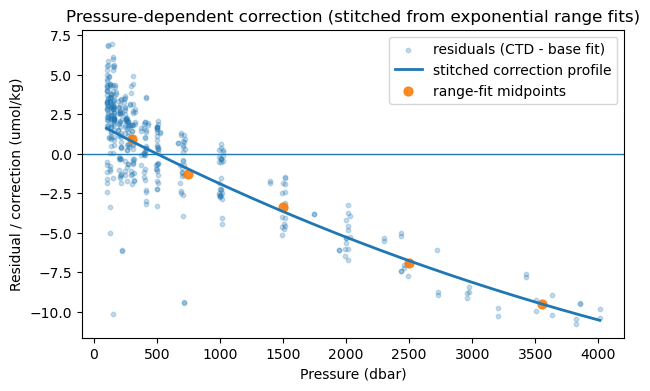

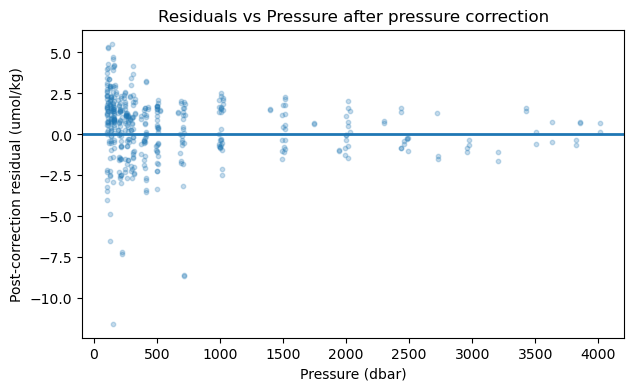

In [51]:
# Spline with exp fit
from dataclasses import dataclass
from typing import List, Sequence, Tuple, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.interpolate import UnivariateSpline
except Exception:
    UnivariateSpline = None

# curve_fit for exponential fitting
try:
    from scipy.optimize import curve_fit
except Exception:  # pragma: no cover
    curve_fit = None


# Exponential model choices


def exp_decay_to_asymptote(p: np.ndarray, A: float, B: float, C: float, Pref: float) -> np.ndarray:
    """
    r(P) = A * exp(B*(P - Pref)) + C
    If B < 0 this decays toward C as pressure increases.
    Pref is a fixed reference pressure (not fitted) to improve numerics.
    """
    return A * np.exp(B * (p - Pref)) + C


def exp_saturating(p: np.ndarray, A: float, B: float, C: float, Pref: float) -> np.ndarray:
    """
    r(P) = A*(1 - exp(-B*(P - Pref))) + C
    If B > 0 it approaches A + C as pressure increases.
    Pref fixed for numerics.
    """
    return A * (1.0 - np.exp(-B * (p - Pref))) + C


@dataclass(frozen=True)
class PressureFit:
    pmin: float
    pmax: float
    n: int
    kind: str  # "exp_decay" or "exp_sat"
    params: Tuple[float, float, float]  # (A, B, C)
    pref: float  # fixed reference pressure used in the model

    def predict(self, p: np.ndarray) -> np.ndarray:
        A, B, C = self.params
        if self.kind == "exp_decay":
            return exp_decay_to_asymptote(p, A, B, C, self.pref)
        elif self.kind == "exp_sat":
            return exp_saturating(p, A, B, C, self.pref)
        else:
            raise ValueError(f"Unknown fit kind: {self.kind}")


# Removes values in surface to avoid strong gradients
def _sanity_filter(df: pd.DataFrame) -> pd.DataFrame:
    return df.query("pressure_ctd > 100 and oxygen_ctd > 0 and oxygen_wink > 0").copy()


# Remove outliers from WinklerO2/CTDO2 keeping values that fall within the 98%
def _drop_outliers_by_ratio(df: pd.DataFrame, qlo: float = 0.01, qhi: float = 0.99) -> pd.DataFrame:
    ratio = df["oxygen_ctd"] / df["oxygen_wink"]
    lo, hi = ratio.quantile([qlo, qhi])
    return df[(ratio > lo) & (ratio < hi)].copy()


# Finds the linear fit between Winkler and CTD (kept as-is)
def fit_ctd_from_wink(df: pd.DataFrame) -> tuple[float, float]:
    x = df["oxygen_wink"].to_numpy(float)
    y = df["oxygen_ctd"].to_numpy(float)
    m, b = np.polyfit(x, y, 1)
    return float(m), float(b)


# ---------------------------
# NEW: exponential per-band fitting
# ---------------------------

def build_piecewise_pressure_fits_exponential(
    df: pd.DataFrame,
    pressure_ranges: Sequence[Tuple[float, float]],
    min_points: int = 8,
    kind: str = "exp_decay",  # "exp_decay" or "exp_sat"
) -> List[PressureFit]:
    """
    Fit residual vs pressure in each band using an exponential model.

    kind="exp_decay": r = A*exp(B*(P-Pref)) + C   (often B<0)
    kind="exp_sat":   r = A*(1-exp(-B*(P-Pref))) + C (often B>0)

    Returns list of PressureFit entries in the same order as pressure_ranges.
    """
    if curve_fit is None:
        raise ImportError("scipy.optimize.curve_fit is required for exponential fits.")

    fits: List[PressureFit] = []
    for pmin, pmax in pressure_ranges:
        sub = df[(df["pressure_ctd"] >= pmin) & (df["pressure_ctd"] < pmax)]
        n = int(len(sub))
        if n < min_points:
            fits.append(PressureFit(float(pmin), float(pmax), n, kind, (np.nan, np.nan, np.nan), np.nan))
            continue

        p = sub["pressure_ctd"].to_numpy(float)
        r = sub["ctd_residual"].to_numpy(float)

        # Fixed reference pressure improves numerical stability
        Pref = float(np.nanmedian(p))

        # Reasonable initial guesses based on the data in the band
        C0 = float(np.nanmedian(r))
        A0 = float((np.nanpercentile(r, 90) - np.nanpercentile(r, 10)) / 2.0)
        if not np.isfinite(A0) or abs(A0) < 1e-6:
            A0 = float(np.nanstd(r)) if np.isfinite(np.nanstd(r)) else 1.0

        if kind == "exp_decay":
            # B typically small negative for decay with pressure
            B0 = -1e-3
            model = lambda pp, A, B, C: exp_decay_to_asymptote(pp, A, B, C, Pref)
            # Loose bounds: keep B within sane range to avoid blow-ups
            bounds = ([-np.inf, -5e-2, -np.inf], [np.inf, 5e-2, np.inf])
        elif kind == "exp_sat":
            # B typically positive for saturation form
            B0 = 1e-3
            model = lambda pp, A, B, C: exp_saturating(pp, A, B, C, Pref)
            bounds = ([-np.inf, 0.0, -np.inf], [np.inf, 5e-2, np.inf])
        else:
            raise ValueError("kind must be 'exp_decay' or 'exp_sat'")

        p0 = (A0, B0, C0)

        try:
            popt, _ = curve_fit(
                model,
                p,
                r,
                p0=p0,
                bounds=bounds,
                maxfev=20000,
            )
            A, B, C = map(float, popt)
            fits.append(PressureFit(float(pmin), float(pmax), n, kind, (A, B, C), Pref))
        except Exception:
            # If a band is poorly conditioned, mark it invalid (same behavior as "insufficient")
            fits.append(PressureFit(float(pmin), float(pmax), n, kind, (np.nan, np.nan, np.nan), Pref))

    return fits


def stitch_fits_with_spline(
    fits: Sequence[PressureFit],
    spline_s: float | None = None,
    k: int = 3,
) -> tuple[np.ndarray, np.ndarray, Callable[[np.ndarray], np.ndarray]]:
    valid = [f for f in fits if np.all(np.isfinite(f.params)) and np.isfinite(f.pref) and f.n > 0]
    if len(valid) < 2:
        raise ValueError("Not enough valid pressure-range fits to stitch. Lower min_points or adjust ranges.")

    p_knots = np.array([(f.pmin + f.pmax) / 2 for f in valid], dtype=float)
    corr_knots = np.array([f.predict(np.array([(f.pmin + f.pmax) / 2], dtype=float))[0] for f in valid], dtype=float)

    order = np.argsort(p_knots)
    p_knots = p_knots[order]
    corr_knots = corr_knots[order]

    if UnivariateSpline is None:
        def interp_fn(p: np.ndarray) -> np.ndarray:
            return np.interp(p, p_knots, corr_knots)
        return p_knots, corr_knots, interp_fn

    spline = UnivariateSpline(p_knots, corr_knots, s=spline_s, k=min(k, len(p_knots) - 1))
    return p_knots, corr_knots, spline


def apply_pressure_correction(df: pd.DataFrame, correction_fn) -> pd.DataFrame:
    df = df.copy()
    p = df["pressure_ctd"].to_numpy(float)
    df["pressure_correction"] = correction_fn(p)
    df["oxygen_ctd_corr"] = df["oxygen_ctd"] - df["pressure_correction"]
    return df


def std_report(df: pd.DataFrame, col: str = "post_residual") -> dict[str, float]:
    r_all = df[col].to_numpy(float)
    r_deep = df.loc[df["pressure_ctd"] > 500, col].to_numpy(float)
    return {
        "n_all": float(len(r_all)),
        "std_all": float(np.nanstd(r_all, ddof=1)),
        "n_deep": float(len(r_deep)),
        "std_deep": float(np.nanstd(r_deep, ddof=1)),
    }


# Applying functions to the data

df = matchall.copy()
df = _sanity_filter(df)
df = _drop_outliers_by_ratio(df, qlo=0.01, qhi=0.99)

# 1) Base fit (CTD from Winkler)
m, b = fit_ctd_from_wink(df)
df["oxygen_ctd_fit_from_wink"] = b + m * df["oxygen_wink"]
df["ctd_residual"] = df["oxygen_ctd"] - df["oxygen_ctd_fit_from_wink"]
print(f"Base fit: oxygen_ctd = {b:.6f} + {m:.6f} * oxygen_wink")

pressure_ranges = [
    (100,500),(500,1000),(1000,2000),(2000,3000),(3000,4100),
]

# 2) Exponential fits over selected pressure ranges
fits = build_piecewise_pressure_fits_exponential(
    df,
    pressure_ranges=pressure_ranges,
    min_points=8,
    kind="exp_decay",  # try "exp_sat" if you expect saturation behavior
)

for f in fits:
    A, B, C = f.params
    if np.all(np.isfinite(f.params)):
        print(f"{f.pmin:>5.0f}-{f.pmax:<5.0f} dbar | n={f.n:>4d} | {f.kind}: A={A:+.4f}, B={B:+.3e}, C={C:+.4f} (Pref={f.pref:.0f})")
    else:
        print(f"{f.pmin:>5.0f}-{f.pmax:<5.0f} dbar | n={f.n:>4d} | fit failed/insufficient")

# 3) Stitch with spline to create correction profile vs pressure
p_knots, corr_knots, corr_spline = stitch_fits_with_spline(fits, spline_s=None, k=3)

# 4) Subtract correction profile from each oxygen observation
df = apply_pressure_correction(df, corr_spline)

df["post_residual"] = df["oxygen_ctd_corr"] - df["oxygen_ctd_fit_from_wink"]

rep = std_report(df, col="post_residual")
print(
    "Accuracy (STD of residuals, umol/kg): "
    f"all={rep['std_all']:.3f} (n={int(rep['n_all'])}), "
    f">500dbar={rep['std_deep']:.3f} (n={int(rep['n_deep'])})"
)

# PLOTS 


plt.figure(figsize=(7, 4))
plt.scatter(df["pressure_ctd"], df["ctd_residual"], s=10, alpha=0.25, label="residuals (CTD - base fit)")
p_grid = np.linspace(df["pressure_ctd"].min(), df["pressure_ctd"].max(), 400)
plt.plot(p_grid, corr_spline(p_grid), lw=2, label="stitched correction profile")
plt.scatter(p_knots, corr_knots, s=40, alpha=0.9, label="range-fit midpoints")
plt.axhline(0, lw=1)
plt.xlabel("Pressure (dbar)")
plt.ylabel("Residual / correction (umol/kg)")
plt.title("Pressure-dependent correction (stitched from exponential range fits)")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(df["pressure_ctd"], df["post_residual"], s=10, alpha=0.25)
plt.axhline(0, lw=2)
plt.xlabel("Pressure (dbar)")
plt.ylabel("Post-correction residual (umol/kg)")
plt.title("Residuals vs Pressure after pressure correction")
plt.show()


In [52]:
# Use the same m, b you fit earlier from matchall
# m, b = fit_ctd_from_wink(df)  # already computed in your script

# Aply correction to all dataset

all_df_corr = all_df_cf.copy()

all_df_corr["pressure"] = pd.to_numeric(all_df_corr["pressure"], errors="coerce")
all_df_corr["oxygen"]   = pd.to_numeric(all_df_corr["oxygen"], errors="coerce")

mask = all_df_corr["pressure"].notna() & all_df_corr["oxygen"].notna()

p_all = all_df_corr.loc[mask, "pressure"].to_numpy(float)

# IMPORTANT: clip to calibration range to avoid spline extrapolation blow-ups
pmin_cal = float(np.nanmin(p_knots))
pmax_cal = float(np.nanmax(p_knots))
p_use = np.clip(p_all, pmin_cal, pmax_cal)

all_df_corr.loc[mask, "pressure_correction"] = corr_spline(p_use)

# 1) remove pressure-dependent residual
o2_noP = all_df_corr.loc[mask, "oxygen"] - all_df_corr.loc[mask, "pressure_correction"]

# 2) map onto Winkler scale (invert base fit)
all_df_corr.loc[mask, "oxygen_corr_winkscale"] = (o2_noP - b) / m


/var/folders/2b/pwxn7kh9125g4k207h_wmc8h0000gn/T/ipykernel_22295/1941705270.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


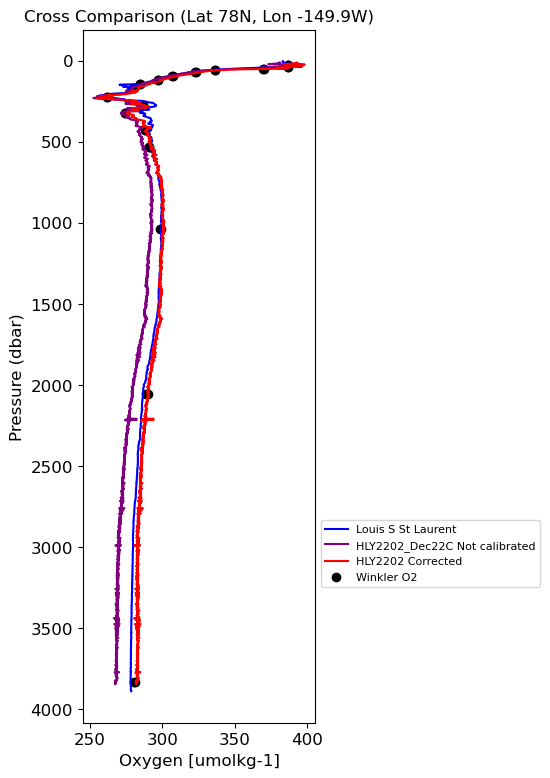

In [53]:
# Plot against comparison profile

compare['density-rho'] = gsw.density.rho(compare[18], compare[3],compare[1])
compare['sigma-den'] = compare['density-rho'] - 1000
compare['oxy'] =(compare[17]*44.6*1000)/(compare['sigma-den']+1000)
winkler = matchall.loc[matchall["Cast_y"].astype(str) == "15"]
station15 = all_df_corr.loc[all_df_corr['Cast'].astype('float64') == 15]

# Plot the data
plt.figure(figsize=(3,9))
plt.plot(compare['oxy'],compare[1],color='blue', markersize=0.1, label= 'Louis S St Laurent')
plt.plot(station15['oxygen'],station15['pressure'],color='purple', markersize=0.1, label= 'HLY2202_Dec22C Not calibrated')
plt.plot(station15['oxygen_corr_winkscale'],station15['pressure'],color='red', markersize=0.1, label= 'HLY2202 Corrected')

plt.scatter(winkler['oxygen_wink'],winkler['pressure_wink'],color='black', marker='o', label= 'Winkler O2')

plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.3), fontsize=8, frameon=True)
plt.gca().invert_yaxis()
plt.xlabel('Oxygen [umolkg-1]',fontsize=12)
plt.ylabel('Pressure (dbar)' ,fontsize=12)
#plt.ylim(500,0)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Cross Comparison (Lat 78N, Lon -149.9W)')
plt.tight_layout()

In [54]:
# Locating max value at the deepest Winkler value: 3832.057, rounded to 3832.0
# The goal is to find the oxygen value at the same depth for each dataset. 
compare_atmax = compare.loc[compare[1] == 3832]
winkler_atmax = winkler.loc[winkler['pressure_wink'] == 3832.057]
station15_atmax = station15.loc[station15['pressure'] == 3832]

winkler_atmax['oxygen_wink'].max(), compare_atmax['oxy'].max() , station15_atmax['oxygen_corr_winkscale'].max(), station15_atmax['oxygen']

(280.8840851,
 278.01453624298074,
 282.3714235785246,
 7747    267.89
 Name: oxygen, dtype: float64)

In [55]:
# max CTD pressure in that cast
pmax = winkler["pressure_ctd"].astype(float).max()

# all rows exactly at that max pressure
deep = winkler.loc[winkler["pressure_ctd"].astype(float) == pmax, ["pressure_ctd", "sigma0", "oxygen_wink", "oxygen_ctd"]]

print("pmax:", pmax)
print("n rows at pmax:", len(deep))
print(deep)

pmax: 3428.0
n rows at pmax: 2
    pressure_ctd     sigma0  oxygen_wink  oxygen_ctd
72        3428.0  28.092691   280.884085     268.199
73        3428.0  28.092691   280.665686     268.199


In [56]:
# computing bias and RMSE of corrected CTD vs Winkler at bottle depths for individual casts. Change cast_id to compute for desired cast. 

# 1) build an interpolator for the corrected CTD profile on that station
def normalize_cast(series: pd.Series) -> pd.Series:
    # extract the first number in the string, convert to Int
    s = series.astype(str).str.strip()
    num = s.str.extract(r"(\d+)")[0]  # grabs digits anywhere
    return pd.to_numeric(num, errors="coerce").astype("Int64")

df["cast_id"]       = normalize_cast(df["Cast_y"])
all_df_corr["cast_id"] = normalize_cast(all_df_corr["Cast"])
# if your Winkler table is df or wink_df:
df["cast_id"] = normalize_cast(df["Cast_y"])  # or wink_df["cast"]

cast_id = 19

prof = all_df_corr[all_df_corr["cast_id"] == cast_id].dropna(
    subset=["pressure", "oxygen_corr_winkscale"]
).sort_values("pressure")

btl = df[df["cast_id"] == cast_id].dropna(
    subset=["pressure_ctd", "oxygen_wink"]
)

print("prof rows:", len(prof), "| bottle rows:", len(btl))

p_prof = prof["pressure"].to_numpy(float)
o_prof = prof["oxygen_corr_winkscale"].to_numpy(float)

p_btl  = btl["pressure_ctd"].to_numpy(float)
o_btl  = btl["oxygen_wink"].to_numpy(float)

o_ctd_at_btl = np.interp(p_btl, p_prof, o_prof)
diff = o_ctd_at_btl - o_btl

print("n bottles:", len(diff))
print("Mean bias:", float(np.mean(diff)))
print("RMSE:", float(np.sqrt(np.mean(diff**2))))
print("Std:", float(np.std(diff, ddof=1)) if len(diff) > 1 else np.nan)


prof rows: 3305 | bottle rows: 30
n bottles: 30
Mean bias: -0.6432937683508707
RMSE: 1.3399091596654558
Std: 1.1954784140119852


In [57]:
import numpy as np
import pandas as pd

def make_cast_id(df, cast_col="Cast_y"):
    df = df.copy()
    df["cast_id"] = (
        df[cast_col]
        .astype(str)
        .str.extract(r"(\d+)")[0]   # extract digits
        .astype(float)
        .astype("Int64")
    )
    return df


df    = make_cast_id(df, "Cast_y")


def compute_cast_bias(cast_id, all_df_corr, df):
    
    prof = all_df_corr[all_df_corr["cast_id"] == cast_id].dropna(
        subset=["pressure", "oxygen_corr_winkscale"]
    ).sort_values("pressure")

    btl = df[df["cast_id"] == cast_id].dropna(
        subset=["pressure_ctd", "oxygen_wink"]
    )

    # skip casts with insufficient data
    if len(prof) < 2 or len(btl) == 0:
        return None

    p_prof = prof["pressure"].to_numpy(float)
    o_prof = prof["oxygen_corr_winkscale"].to_numpy(float)

    p_btl = btl["pressure_ctd"].to_numpy(float)
    o_btl = btl["oxygen_wink"].to_numpy(float)

    # interpolate corrected CTD to bottle pressures
    o_interp = np.interp(p_btl, p_prof, o_prof)
    diff = o_interp - o_btl

    return {
        "cast_id": cast_id,
        "n": len(diff),
        "bias": np.mean(diff),
        "rmse": np.sqrt(np.mean(diff**2)),
        "std": np.std(diff, ddof=1) if len(diff) > 1 else np.nan
    }

results = []

for cast_id in sorted(df["cast_id"].dropna().unique()):
    r = compute_cast_bias(cast_id, all_df_corr, df)
    if r is not None:
        results.append(r)

bias_df = pd.DataFrame(results)
print(bias_df.head())

print("Overall bias:", bias_df["bias"].mean())
print("Overall RMSE:", np.sqrt(np.mean(bias_df["rmse"]**2)))


   cast_id   n      bias      rmse       std
0       11  20  0.903328  3.120675  3.064673
1       13   2  1.557135  1.603832  0.543337
2       14   4  3.231945  3.387086  1.170118
3       15  21  2.448454  2.782274  1.354042
4       17   2 -2.333287  2.343974  0.316185
Overall bias: 0.8544191979435092
Overall RMSE: 2.3064647154441933


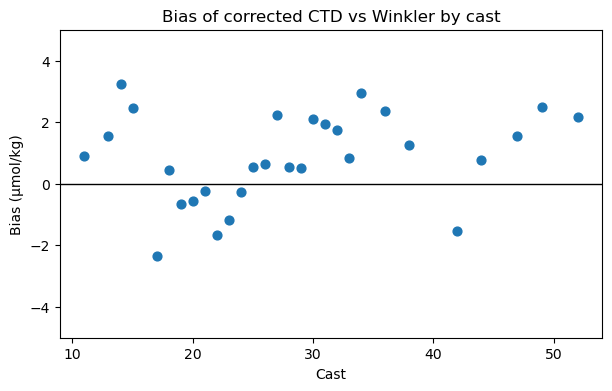

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.axhline(0, color="black", linewidth=1)
plt.scatter(bias_df["cast_id"], bias_df["bias"], s=40)
plt.ylim(-5, 5)
plt.xlabel("Cast")
plt.ylabel("Bias (µmol/kg)")
plt.title("Bias of corrected CTD vs Winkler by cast")
plt.show()


In [71]:
mean_bias = bias_df["bias"].mean()
std_bias  = bias_df["bias"].std(ddof=1)

print(f"Bias = {mean_bias:.2f} ± {std_bias:.2f} µmol/kg")


Bias = 0.85 ± 1.46 µmol/kg


In [59]:
# keep only first casts (0–10) from all_df
all_df_first = all_df[all_df["Cast"].between(0, 10, inclusive="both")].copy()

# optional: keep only columns you care about (prevents column clutter)
# cols_keep = ["Cast","pressure","oxygen","oxygen_sensor_corr","oxy_sensor_factor","_source", ...]
# all_df_first = all_df_first[cols_keep].copy()

# combine
combined_df = pd.concat([all_df_first, all_df_corr], ignore_index=True)

mask_early = combined_df["Cast"].between(0, 10, inclusive="both")

# Make sensor correction "not applicable" outside 0–10
combined_df.loc[~mask_early, "oxygen_sensor_corr"] = np.nan

# Hybrid: early uses sensor, rest uses winkler
combined_df["oxygen_corr_hybrid"] = combined_df["oxygen_sensor_corr"].combine_first(
    combined_df["oxygen_corr_winkscale"]
)



In [60]:


print("Rows with sensor correction:",
      combined_df["oxygen_sensor_corr"].notna().sum())

print("Rows with hybrid correction:",
      combined_df["oxygen_corr_hybrid"].notna().sum())

print("Casts present:",
      sorted(combined_df["Cast"].dropna().unique())[:53])


Rows with sensor correction: 2052
Rows with hybrid correction: 43397
Casts present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]


In [61]:
print("rows with oxygen_sensor_corr:", combined_df["oxygen_sensor_corr"].notna().sum())
print("rows with oxygen_corr_winkscale:", combined_df["oxygen_corr_winkscale"].notna().sum())
print("rows with either correction:",
      (combined_df["oxygen_sensor_corr"].notna() | combined_df["oxygen_corr_winkscale"].notna()).sum())


rows with oxygen_sensor_corr: 2052
rows with oxygen_corr_winkscale: 41366
rows with either correction: 43397


In [62]:
c = 20
print(combined_df.loc[combined_df["Cast"] == c,
                      ["oxygen_sensor_corr","oxygen_corr_winkscale","oxygen_corr_hybrid"]].head(10))


       oxygen_sensor_corr  oxygen_corr_winkscale  oxygen_corr_hybrid
15555                 NaN             402.204438          402.204438
15556                 NaN             402.738007          402.738007
15557                 NaN             402.604615          402.604615
15558                 NaN             402.665932          402.665932
15559                 NaN             402.556206          402.556206
15560                 NaN             402.193681          402.193681
15561                 NaN             402.129136          402.129136
15562                 NaN             402.033395          402.033395
15563                 NaN             402.065667          402.065667
15564                 NaN             401.415918          401.415918


In [63]:
print(combined_df.loc[combined_df["Cast"] == 3,
      ["oxygen_sensor_corr","oxygen_corr_winkscale","oxygen_corr_hybrid"]].head())

print(combined_df.loc[combined_df["Cast"] == 20,
      ["oxygen_sensor_corr","oxygen_corr_winkscale","oxygen_corr_hybrid"]].head())


     oxygen_sensor_corr  oxygen_corr_winkscale  oxygen_corr_hybrid
128          340.852121                    NaN          340.852121
129          340.875296                    NaN          340.875296
130          340.463192                    NaN          340.463192
131          340.495435                    NaN          340.495435
132          340.719120                    NaN          340.719120
       oxygen_sensor_corr  oxygen_corr_winkscale  oxygen_corr_hybrid
15555                 NaN             402.204438          402.204438
15556                 NaN             402.738007          402.738007
15557                 NaN             402.604615          402.604615
15558                 NaN             402.665932          402.665932
15559                 NaN             402.556206          402.556206


oxygen_sensor_corr = from sensor 1 (Cast0-8)

oxygen_corr_winkscale = second sensor

oxygen_corr_hybrid = all ctd files corrected with respective method. 

# Converting data to .ncfile for publication

In [64]:
combined_df.columns

Index(['cast', '_source', 'pressure', 'depth', 'temperature', 'salinity',
       'oxygen', 'latitude', 'longitude', 'SA', 'theta', 'CT', 'sigma0',
       'Cast', 'oxy_sensor_factor', 'oxygen_sensor_corr',
       'pressure_correction', 'oxygen_corr_winkscale', 'cast_id',
       'oxygen_corr_hybrid'],
      dtype='object')

In [65]:

def calc_oxygen_properties(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute oxygen solubility, saturation, and AOU
    using oxygen_corr_hybrid (not raw oxygen).
    """
    df = df.copy()

    # Require needed columns
    required = {"temperature", "salinity", "oxygen_corr_hybrid"}
    if not required.issubset(df.columns):
        raise ValueError(f"Missing required columns: {required - set(df.columns)}")

    # Convert to numeric arrays safely
    T = pd.to_numeric(df["temperature"], errors="coerce").to_numpy(float)
    S = pd.to_numeric(df["salinity"], errors="coerce").to_numpy(float)
    O2 = pd.to_numeric(df["oxygen_corr_hybrid"], errors="coerce").to_numpy(float)

    # Oxygen solubility (Garcia & Gordon)
    temp_S = np.log((298.15 - T) / (273.15 + T))
    exp_O2 = np.exp(
        A0_o2 + A1_o2*temp_S + A2_o2*(temp_S**2) + A3_o2*(temp_S**3) +
        A4_o2*(temp_S**4) + A5_o2*(temp_S**5)
        + S*(B0_o2 + B1_o2*temp_S + B2_o2*(temp_S**2) + B3_o2*(temp_S**3))
        + C0_o2*(S**2)
    )

    # Store results
    df["exp_O2umolkg"] = exp_O2
    df["Sat_O2umolkg"] = (O2 / exp_O2) * 100.0
    df["AOU"] = exp_O2 - O2

    return df

combined_df = calc_oxygen_properties(combined_df)

In [66]:
combined_df.columns

Index(['cast', '_source', 'pressure', 'depth', 'temperature', 'salinity',
       'oxygen', 'latitude', 'longitude', 'SA', 'theta', 'CT', 'sigma0',
       'Cast', 'oxy_sensor_factor', 'oxygen_sensor_corr',
       'pressure_correction', 'oxygen_corr_winkscale', 'cast_id',
       'oxygen_corr_hybrid', 'exp_O2umolkg', 'Sat_O2umolkg', 'AOU'],
      dtype='object')

In [75]:
import xarray as xr

# Ensure sorted unique dimensions
casts     = np.sort(combined_df["Cast"].unique())
pressures = np.sort(combined_df["pressure"].unique())

def reshape(varname):
    return combined_df.pivot_table(
        index="Cast",
        columns="pressure",
        values=varname
    ).reindex(index=casts, columns=pressures)

ds = xr.Dataset(
    data_vars={
        "depth":   (("Cast", "pressure"), reshape("depth").to_numpy()),
        "temperature":   (("Cast", "pressure"), reshape("temperature").to_numpy()),
        "CT":   (("Cast", "pressure"), reshape("CT").to_numpy()),
        "salinity":   (("Cast", "pressure"), reshape("salinity").to_numpy()),
        "SA":   (("Cast", "pressure"), reshape("SA").to_numpy()),
        "sigma0":   (("Cast", "pressure"), reshape("sigma0").to_numpy()),
        "oxygen_unc":   (("Cast", "pressure"), reshape("oxygen").to_numpy()),
        "oxygen_corr":  (("Cast", "pressure"), reshape("oxygen_corr_hybrid").to_numpy()),
        "oxy_sensor1_factor":  (("Cast", "pressure"), reshape("oxy_sensor_factor").to_numpy()),
        "pressure_correction": (("Cast", "pressure"), reshape("pressure_correction").to_numpy()),
        "oxygen_corr_winkscale": (("Cast", "pressure"), reshape("oxygen_corr_winkscale").to_numpy()),
        "oxygen_corr_hybrid": (("Cast", "pressure"), reshape("oxygen_corr_hybrid").to_numpy()),
        "exp_O2umolkg": (("Cast", "pressure"), reshape("exp_O2umolkg").to_numpy()),
        "Sat_O2umolkg": (("Cast", "pressure"), reshape("Sat_O2umolkg").to_numpy()),
        "AOU": (("Cast", "pressure"), reshape("AOU").to_numpy()),
    },
    coords={
        "Cast": casts,
        "pressure": pressures,
        "latitude": ("Cast", combined_df.groupby("Cast")["latitude"].first().reindex(casts)),
        "longitude": ("Cast", combined_df.groupby("Cast")["longitude"].first().reindex(casts)),
    },
    attrs=dict(
        description="CTD dissolved oxygen calibration dataset from the HLY2202 expedition (4 September–24 October 2022, USCGC Healy). A total of 865 discrete water samples were collected from 37 CTD stations and analyzed using the Carpenter-modified Winkler titration method (Langdon, 2010) with an amperometric titrator. After QC, 824 Winkler samples were used for CTD oxygen correction (casts 0–10: n=68; casts 10–53: n=756). CTD oxygen profiles were paired with Winkler samples within cast using potential density anomaly (sigma0) matching with nearest-neighbor association and tolerance ±0.05 kg m^-3. For casts 0-10 linear CTD–Winkler calibration (CF) was applied from fits of WinklerO2/CTDO2. For casts 10-53, baseline linear calibration fit between Winkler O2 and CTDO2 was applied and residuals were modeled versus pressure using exponential fits within pressure intervals and combined via spline interpolation to generate a continuous pressure-dependent correction, which was subtracted from CTD oxygen to produce the final calibrated variable. Calibration statistics (30 bottle matches; 3305 profile rows): mean residual = −0.64 µmol kg^-1; RMSE = 1.34 µmol kg^-1; residual standard deviation (1σ) = 1.20 µmol kg^-1."
    ),
)

# Metadata dictionary for variables
var_metadata = {
    "depth": {
        "long_name": "depth",
        "units": "m",
    },
    "salinity": {
        "long_name": "practical salinity",
        "units": "psu",
    },
    "SA": {
        "long_name": "absolute salinity",
        "units": "g/kg",
    },
    "temperature": {
        "long_name": "temperature",
        "units": "degree_C (ITS-90)",
    },
    "sigma0": {
        "long_name": "potential density with reference pressure of 0 dbar",
        "units": "kg/m3",
    },
    "CT": {
        "long_name": "conservative temperature",
        "units": "degree_C (ITS-90)",
    },
    "oxygen_unc": {
        "long_name": "uncorrected oxygen from CTD",
        "units": "umol/kg",
    },
    "oxygen_corr": {
        "long_name": "corrected oxygen from CTD",
        "units": "umol/kg",
    },
    "oxy_sensor1_factor": {
        "long_name": "CF derived from mean ratio Winkler[O₂]/SBE43[O₂] from sensor1.",
        "units": "",
    },
    "pressure_correction": {
        "long_name": "Pressure-dependent residual correction term applied to CTD O2 from sensor2",
        "units": "umol/kg",

    },
    "oxygen_corr_winkscale": {
        "long_name": "corrected oxygen from pressure-dependent exponential spline interpolation",
        "units": "umol/kg",
    },
    "oxygen_corr_hybrid": {
        "long_name": "corrected oxygen using sensor CF for casts 0-10, then pressure-dependent spline CF for rest of casts",
        "units": "umol/kg",
    },
    "exp_O2umolkg": {
        "long_name": "Oxygen solubility (equilibrium concentration), calculated using constants for O2 solubility (Garcia & Gordon fit to Benson & Krause)",
        "units": "umol/kg",
    },
    "Sat_O2umolkg": {
        "long_name": "saturation of O2",
        "units": "%",
    },
    "AOU": {
        "long_name": "AOU (apparent oxygen utilization)",
        "units": "umol/kg",
    }
}


ds.attrs.update({
    "title": "Calibrated CTD Oxygen Dataset",
    "summary": "Dataset with pressure-dependent and constant CF corrections applied to CTD oxygen from the HLY2202 expedition, calibrated against discrete Winkler titration samples. Contains both corrected and uncorrected oxygen, as well as computed oxygen properties (saturation, AOU).",
    "history": "865 Winkler samples collected (HLY2202); 824 passed QC and were used for CTD oxygen calibration (casts 0–10: n=68; casts 10–53: n=756). CTD–Winkler pairs matched within cast using sigma0 tolerance ±0.05 kg m^-3. Depth-dependent residuals modeled with exponential fits and spline interpolation; correction applied to CTD oxygen. Final residual statistics: mean = −0.64 µmol kg^-1; RMSE = 1.34 µmol kg^-1; 1σ = 1.20 µmol kg^-1.",
    "creator": "Maria Cristina Alvarez Rodriguez",
    "institution": "Oregon State University, now at University of Southampton",
    "contact": "mcar1u25@soton.ac.uk",
})

# loop to add attrs
for var, attrs in var_metadata.items():
    if var in ds.data_vars:  # ensures variable exists
        data = ds[var]

        ds[var].attrs.update({
            "long_name": attrs["long_name"],
            "units": attrs["units"],
            "valid_min": float(data.min().values),
            "valid_max": float(data.max().values),
        })

# metadata for coordinates
coord_metadata = {
    "latitude":  {"long_name": "latitude",  "units": "degrees_north"},
    "longitude": {"long_name": "longitude", "units": "degrees_east"},
    "pressure":  {"long_name": "pressure",  "units": "decibar"},
    "cast":      {"long_name": "cast number", "units": "1"},
}

# loop to add attrs
for coord, attrs in coord_metadata.items():
    if coord in ds.coords:
        data = ds[coord]

        ds[coord].attrs.update({
            "long_name": attrs["long_name"],
            "units": attrs["units"],
            "valid_min": float(data.min().values),
            "valid_max": float(data.max().values),
        })

print(ds)

<xarray.Dataset> Size: 27MB
Dimensions:                (Cast: 53, pressure: 4296)
Coordinates:
  * Cast                   (Cast) int64 424B 1 2 3 4 5 6 7 ... 48 49 50 51 52 53
  * pressure               (pressure) float64 34kB 1.0 2.0 ... 4.296e+03
    latitude               (Cast) float64 424B 71.59 72.38 72.48 ... 72.82 67.68
    longitude              (Cast) float64 424B -161.5 -158.9 ... -158.3 -169.0
Data variables: (12/15)
    depth                  (Cast, pressure) float64 2MB nan 1.979 ... nan nan
    temperature            (Cast, pressure) float64 2MB nan 3.094 ... nan nan
    CT                     (Cast, pressure) float64 2MB nan 3.146 ... nan nan
    salinity               (Cast, pressure) float64 2MB nan 28.26 ... nan nan
    SA                     (Cast, pressure) float64 2MB nan 28.4 ... nan nan
    sigma0                 (Cast, pressure) float64 2MB nan 22.51 ... nan nan
    ...                     ...
    pressure_correction    (Cast, pressure) float64 2MB nan nan nan 

In [76]:
ds['pressure_correction']

<xarray.DataArray 'pressure_correction' (Cast: 53, pressure: 4296)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * Cast       (Cast) int64 424B 1 2 3 4 5 6 7 8 9 ... 46 47 48 49 50 51 52 53
  * pressure   (pressure) float64 34kB 1.0 2.0 3.0 ... 4.295e+03 4.296e+03
    latitude   (Cast) float64 424B 71.59 72.38 72.48 72.54 ... 72.69 72.82 67.68
    longitude  (Cast) float64 424B -161.5 -158.9 -158.9 ... -161.7 -158.3 -169.0
Attributes:
    long_name:  Pressure-dependent residual correction term applied to CTD O2...
    units:      umol/kg
    valid_min:  -9.513826509015315
    valid_max:  0.7906802256437628

In [77]:
combined_df.to_pickle('/Users/mariacristinaalvarez/Documents/Github/ArcticO2/HLY2022_data/expspline_hly2202_corr.pkl')

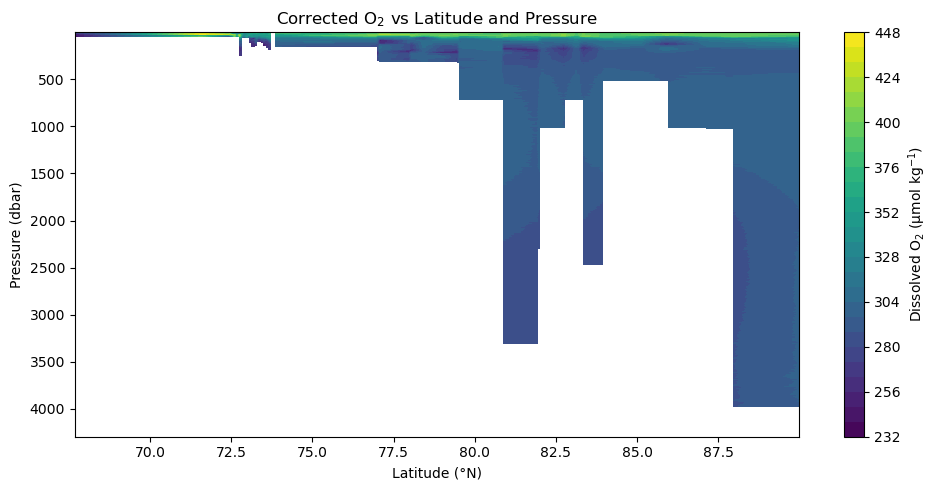

In [78]:
# Sort dataset by latitude
# 1) Sort by latitude so the coordinate is monotonic

ds_lat = ds.sortby("latitude")

ds_lat = ds_lat.swap_dims({"Cast": "latitude"})


# 3) New regular latitude grid
lat_new = np.linspace(
    float(ds_lat["latitude"].min()),
    float(ds_lat["latitude"].max()),
    300
)

# 4) Interpolate along latitude (now a dimension!)
O2_lat_sec = ds_lat["oxygen_corr_hybrid"].interp(latitude=lat_new)

# 5) Pressure coordinate
p = ds_lat["pressure"]



fig, ax = plt.subplots(figsize=(10, 5))

cs = ax.contourf(
    lat_new,
    p,
    O2_lat_sec.T,   # transpose so shape is (pressure, latitude)
    levels=30
)

cbar = plt.colorbar(cs, ax=ax)
cbar.set_label("Dissolved O$_2$ (μmol kg$^{-1}$)")

ax.set_xlabel("Latitude (°N)")
ax.set_ylabel("Pressure (dbar)")
ax.invert_yaxis()
ax.set_title("Corrected O$_2$ vs Latitude and Pressure")

plt.tight_layout()
plt.show()


In [79]:

ds.to_netcdf("/Users/mariacristinaalvarez/Documents/Github/ArcticO2/HLY2022_data/hly2202_oxycorr_expspline.nc", mode="w")

# From here and Below it's investigative code, do not use


In [ ]:
# Linear fit Spline Interp. Frankestein

from dataclasses import dataclass
from typing import Callable, List, Sequence, Tuple

import numpy as np
import pandas as pd

from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline


# ---------------------------
# Models
# ---------------------------

def exponential_func(p: np.ndarray, a: float, b: float, c: float) -> np.ndarray:
    """CF(P) = a * exp(b * P) + c"""
    p = np.asarray(p, float)
    return a * np.exp(b * p) + c


@dataclass(frozen=True)
class PressureFit:
    pmin: float
    pmax: float
    n: int
    slope: float
    intercept: float

    def predict(self, p: np.ndarray) -> np.ndarray:
        return self.slope * p + self.intercept

def smoothstep(x: np.ndarray, x0: float, x1: float) -> np.ndarray:
    t = np.clip((x - x0) / (x1 - x0), 0.0, 1.0)
    return t * t * (3 - 2 * t)

def apply_piecewise_blend(
    df: pd.DataFrame,
    cf_fn,              # CF(P) exponential
    deep_corr_fn,       # residual spline correction (additive)
    p_col: str,
    o2_col: str,
    out_col: str = "oxygen_corr",
    p_start: float = 1900.0,
    p_end: float = 2100.0,
) -> pd.DataFrame:
    out = df.copy()
    out[p_col] = pd.to_numeric(out[p_col], errors="coerce")
    out[o2_col] = pd.to_numeric(out[o2_col], errors="coerce")

    m = out[p_col].notna() & out[o2_col].notna()
    p = out.loc[m, p_col].to_numpy(float)
    o2 = out.loc[m, o2_col].to_numpy(float)

    # Branch 1: multiplicative (CF)
    o2_shallow = o2 * cf_fn(p)

    # Branch 2: additive (residual spline)
    o2_deep = o2 - deep_corr_fn(p)

    # Blend weight: 0 at 1900 -> 1 at 2100
    w = smoothstep(p, p_start, p_end)

    out.loc[m, out_col] = (1 - w) * o2_shallow + w * o2_deep
    out.loc[m, "blend_w"] = w
    return out


# ---------------------------
# Shallow: CF exponential fit
# ---------------------------

def fit_exponential_cf(
    matchall: pd.DataFrame,
    p_switch: float = 1500.0,
    p_col: str = "pressure_ctd",
    wink_col: str = "oxygen_wink",
    ctd_col: str = "oxygen_ctd",
    initial_guess: Tuple[float, float, float] = (1.06, -0.001, 1.01),
    qlo: float = 0.01,
    qhi: float = 0.99,
) -> Tuple[Tuple[float, float, float], Callable[[np.ndarray], np.ndarray]]:
    """
    Fit CF(P)=wink/ctd for pressures <= p_switch using CF(P)=a*exp(bP)+c.
    """
    df = matchall[[p_col, wink_col, ctd_col]].copy()
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df[wink_col] = pd.to_numeric(df[wink_col], errors="coerce")
    df[ctd_col] = pd.to_numeric(df[ctd_col], errors="coerce")
    df = df.dropna()
    df = df[(df[p_col] >= 0) & (df[p_col] <= p_switch) & (df[wink_col] > 0) & (df[ctd_col] > 0)].copy()

    df["CF"] = df[wink_col] / df[ctd_col]
    lo, hi = df["CF"].quantile([qlo, qhi])
    df = df[(df["CF"] >= lo) & (df["CF"] <= hi)].copy()

    p = df[p_col].to_numpy(float)
    cf = df["CF"].to_numpy(float)

    popt, pcov = curve_fit(exponential_func, p, cf, p0=initial_guess, maxfev=20000)

    def cf_fn(pp: np.ndarray) -> np.ndarray:
        return exponential_func(np.asarray(pp, float), *popt)

    return (float(popt[0]), float(popt[1]), float(popt[2])), cf_fn


# ---------------------------
# Deep: residual spline (your method)
# ---------------------------

def build_piecewise_pressure_fits(
    df: pd.DataFrame,
    pressure_ranges: Sequence[Tuple[float, float]],
    p_col: str = "pressure_ctd",
    r_col: str = "ctd_residual",
    min_points: int = 8,
) -> List[PressureFit]:
    fits: List[PressureFit] = []
    for pmin, pmax in pressure_ranges:
        sub = df[(df[p_col] >= pmin) & (df[p_col] < pmax)]
        n = int(len(sub))
        if n < min_points:
            fits.append(PressureFit(pmin, pmax, n, np.nan, np.nan))
            continue
        p = sub[p_col].to_numpy(float)
        r = sub[r_col].to_numpy(float)
        a, c = np.polyfit(p, r, 1)
        fits.append(PressureFit(float(pmin), float(pmax), n, float(a), float(c)))
    return fits


def stitch_fits_with_spline(
    fits: Sequence[PressureFit],
    spline_s: float | None = 5.0,
    k: int = 3,
) -> Tuple[np.ndarray, np.ndarray, Callable[[np.ndarray], np.ndarray]]:
    valid = [f for f in fits if np.isfinite(f.slope) and np.isfinite(f.intercept) and f.n > 0]
    if len(valid) < 2:
        raise ValueError("Not enough valid fits to build spline.")

    p_knots = np.array([(f.pmin + f.pmax) / 2 for f in valid], dtype=float)
    corr_knots = np.array([f.predict(np.array([(f.pmin + f.pmax) / 2], dtype=float))[0] for f in valid], dtype=float)

    order = np.argsort(p_knots)
    p_knots, corr_knots = p_knots[order], corr_knots[order]

    spline = UnivariateSpline(p_knots, corr_knots, s=spline_s, k=min(k, len(p_knots) - 1))
    return p_knots, corr_knots, spline


# ---------------------------
# Apply piecewise to any CTD dataframe
# ---------------------------

def apply_piecewise_ctd_correction(
    ctd_df: pd.DataFrame,
    cf_fn: Callable[[np.ndarray], np.ndarray],
    deep_corr_fn: Callable[[np.ndarray], np.ndarray],
    p_switch: float = 1900,
    p_col: str = "pressure",
    o2_col: str = "oxygen",
    out_col: str = "oxygen_corr",
) -> pd.DataFrame:
    """
    Piecewise apply:
      - shallow: oxygen_corr = oxygen * CF(P)
      - deep:   oxygen_corr = oxygen - deep_corr(P)
    """
    out = ctd_df.copy()
    out[p_col] = pd.to_numeric(out[p_col], errors="coerce")
    out[o2_col] = pd.to_numeric(out[o2_col], errors="coerce")

    mask = out[p_col].notna() & out[o2_col].notna()
    p = out.loc[mask, p_col].to_numpy(float)
    o2 = out.loc[mask, o2_col].to_numpy(float)

    shallow = p <= p_switch
    corr = np.full_like(o2, np.nan, dtype=float)

    if shallow.any():
        corr[shallow] = o2[shallow] * cf_fn(p[shallow])
    if (~shallow).any():
        corr[~shallow] = o2[~shallow] - deep_corr_fn(p[~shallow])

    out.loc[mask, out_col] = corr
    out.loc[mask, "corr_branch"] = np.where(shallow, f"CF_exp<= {p_switch:g}", f"resid_spline> {p_switch:g}")
    return out


# ---------------------------


p_switch =1900

# 1) Fit shallow exponential CF(P) 
(a, b, c), cf_fn = fit_exponential_cf(
    matchall,
    p_switch=p_switch,
    initial_guess=(1.06, -0.001, 1.01),
)
print(f"Shallow CF fit: CF(P) = {a:.6f} * exp({b:.6e} * P) + {c:.6f}")

# 2) Build deep residual spline using matchall residuals method
df = matchall.copy()
df = df.query("pressure_ctd > 100 and oxygen_ctd > 0 and oxygen_wink > 0").copy()
df["CF"] = df["oxygen_wink"] / df["oxygen_ctd"]

# base fit to define residuals (your existing step)
m, bb = np.polyfit(df["oxygen_wink"].to_numpy(float), df["oxygen_ctd"].to_numpy(float), 1)
df["oxygen_ctd_fit_from_wink"] = bb + m * df["oxygen_wink"]
df["ctd_residual"] = df["oxygen_ctd"] - df["oxygen_ctd_fit_from_wink"]

# IMPORTANT: fit residual spline using ONLY deep portion if that's your intent
df_deep = df[df["pressure_ctd"] > p_switch].copy()

pressure_ranges = [
    (1900,2600),(2600,3000), (3000,3500),(3500,4100),
]
fits = build_piecewise_pressure_fits(df_deep, pressure_ranges=pressure_ranges, min_points=8)
p_knots, corr_knots, deep_corr_fn = stitch_fits_with_spline(fits, spline_s=5.0, k=3)

# 3) Apply to full CTD dataset (all_df_cf)
# Adjust col names if needed:
# - if your CTD df uses pressure_ctd/oxygen_ctd, set p_col/o2_col accordingly
all_df_corr2 = apply_piecewise_ctd_correction(
    all_df_cf,
    cf_fn=cf_fn,
    deep_corr_fn=deep_corr_fn,
    p_switch=p_switch,
    p_col="pressure",
    o2_col="oxygen",
    out_col="oxygen_corr",
)


In [ ]:
compare['density-rho'] = gsw.density.rho(compare[18], compare[3],compare[1])
compare['sigma-den'] = compare['density-rho'] - 1000
compare['oxy'] =(compare[17]*44.6*1000)/(compare['sigma-den']+1000)
winkler = matchall.loc[matchall["Cast_y"].astype(str) == "15"]
station15 = all_df_corr2.loc[all_df_corr2['Cast'].astype('float64') == 15]

# Plot the data
plt.figure(figsize=(3,9))
plt.plot(compare['oxy'],compare[1],color='blue', markersize=0.5, label= 'Louis S St Laurent')
plt.plot(station15['oxygen'],station15['pressure'],color='purple', markersize=0.1, label= 'HLY2202_Dec22C Not calibrated')
plt.plot(station15['oxygen_corr'],station15['pressure'],color='red', markersize=0.1, label= 'HLY2202 Corrected')
plt.scatter(winkler['oxygen_wink'],winkler['pressure_wink'],color='black', marker='o', label= 'Winkler O2')

plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.3), fontsize=8, frameon=True)
plt.gca().invert_yaxis()
plt.xlabel('Oxygen [umolkg-1]',fontsize=12)
plt.ylabel('Pressure (dbar)' ,fontsize=12)
#plt.ylim(top=1000)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Cross Comparison (Lat 78N, Lon -149.9W) Half press-depndent expo function then residuals spline correction')
plt.tight_layout()

In [ ]:
# Locating max value at the deepest Winkler value: 3832.057, rounded to 3832.0
# The goal is to find the oxygen value at the same depth for each dataset. 

station15_atmax = station15.loc[station15['pressure'] == 3832]

winkler_atmax['oxygen_wink'].max(), compare_atmax['oxy'].max() , station15_atmax['oxygen_corr'].max(), station15_atmax['oxygen']

In [ ]:
# NOT USED - EXPONENTIAL FIT

exp_df = matchall.copy()

# basic sanity filters
exp_df = exp_df.query(
    "pressure_ctd > 100 and "
    "oxygen_ctd > 0 and "
    "oxygen_wink > 0"
).copy()

from scipy.optimize import curve_fit
def exp_decay(x, a, b, c):
    return a * (1 - np.exp(-b * x)) + c

# Define the exponential function
def exponential_func(x, a, b, c):
    return a * np.exp(b * x) + c


# Provide initial guesses for the parameters 
initial_guess = [1.06, -0.01, 1.01]

exp_df['CF'].sort_values(ascending=True)
# Provide initial guesses for the parameters 
initial_guess = [1.06, -0.01, 1.01]


# Fit the nonlinear model
popt_exp, pcov = curve_fit(exponential_func, exp_df['pressure_ctd'], exp_df['CF'], p0=initial_guess)

plt.figure(figsize=[5,4])
plt.scatter(exp_df['pressure_ctd'], exp_df['CF'], label='CF without outliers', c='#298c8c', s=15, zorder=5)
plt.scatter(exp_df['pressure_ctd'], exp_df['CF'] ,c= '#800074', s=13, label='CF with outliers')
# Plot the fitted curve
x_fit = np.linspace(min(exp_df['pressure_ctd']), max(exp_df['pressure_ctd']), 100)
y_fit = exponential_func(x_fit, *popt_exp)
plt.plot(x_fit, y_fit, 'r', label='Exponential Fit', c='#bc272d')
#plt.xlim(left = 2500)
plt.xlabel('Pressure_ctd (dbar)',fontsize=12)
plt.ylabel('CF' ,fontsize=12)
plt.legend()
plt.title('Exponential equation fit with Align 7s')
plt.show()

In [ ]:
#Correcting values from a pressure dependent log and exp fit
matchall['CF_exp'] = exponential_func(matchall['pressure_ctd'], *popt_exp)
matchall['O2_correct_exp'] = matchall['oxygen_ctd'] * matchall['CF_exp']

#Correcting values. Only using northbound for cross-comparison reasons
all_df['CF_exp'] = exponential_func(all_df['pressure'], *popt_exp)
all_df['oxygen_exp'] = all_df['oxygen'] * all_df['CF_exp']

In [ ]:
compare['density-rho'] = gsw.density.rho(compare[18], compare[3],compare[1])
compare['sigma-den'] = compare['density-rho'] - 1000
compare['oxy'] =(compare[17]*44.6*1000)/(compare['sigma-den']+1000)
winkler = matchall.loc[matchall["Cast_y"].astype(str) == "15"]

station15 = all_df.loc[all_df['Cast'].astype('float64') == 15]
# Plot the data SALINITY
plt.figure(figsize=(3,10))
plt.plot(compare['oxy'],compare[1],color='blue', markersize=0.1, label= 'Louis S St Laurent')
plt.plot(station15['oxygen'],station15['pressure'],color='purple', markersize=0.1, label= 'HLY2202_Dec22C Not calibrated')
plt.plot(station15['oxygen_exp'],station15['pressure'],color='red', markersize=0.1, label= 'HLY2202 Corrected with Exponential Fit')
#plt.plot(station15['oxygen_log'],station15[0],color='green', markersize=0.5, label= 'HLY2202 Corrected with Logarithmic Fit')

#station15_W  = stations_df.loc[stations_df['Cast'] == 15]
plt.scatter(winkler['oxygen_wink'],winkler['pressure_wink'],color='black', marker='o', label= 'Winkler O2')

plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.3), fontsize=8, frameon=True)
plt.gca().invert_yaxis()
plt.xlabel('Oxygen [umolkg-1]',fontsize=12)
plt.ylabel('Pressure (dbar)' ,fontsize=12)
#lt.ylim(top=500)
plt.xlim(left= 250, right=320)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Cross Comparison (Lat 78N, Lon -149.9W) Exp Fit, ALign7s')
plt.tight_layout()

/var/folders/2b/pwxn7kh9125g4k207h_wmc8h0000gn/T/ipykernel_56098/908123247.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


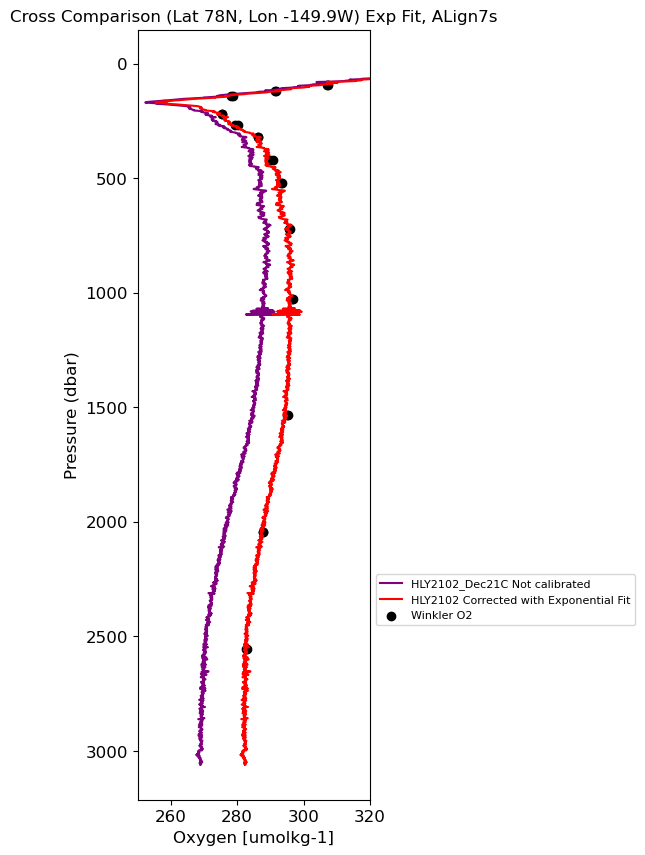

In [62]:

winkler21 = matchall.loc[matchall["Cast_y"].astype(str) == "21"]

station21 = all_df.loc[all_df['Cast'].astype('float64') == 21]
# Plot the data SALINITY
plt.figure(figsize=(3,10))
#plt.plot(compare['oxy'],compare[1],color='blue', markersize=0.1, label= 'Louis S St Laurent')
plt.plot(station21['oxygen'],station21['pressure'],color='purple', markersize=0.1, label= 'HLY2102_Dec21C Not calibrated')
plt.plot(station21['oxygen_exp'],station21['pressure'],color='red', markersize=0.1, label= 'HLY2102 Corrected with Exponential Fit')
#plt.plot(station21['oxygen_log'],station21[0],color='green', markersize=0.5, label= 'HLY2102 Corrected with Logarithmic Fit')

#station21_W  = stations_df.loc[stations_df['Cast'] == 21]
plt.scatter(winkler21['oxygen_wink'],winkler21['pressure_wink'],color='black', marker='o', label= 'Winkler O2')

plt.legend(loc='upper left', bbox_to_anchor=(1.0, 0.3), fontsize=8, frameon=True)
plt.gca().invert_yaxis()
plt.xlabel('Oxygen [umolkg-1]',fontsize=12)
plt.ylabel('Pressure (dbar)' ,fontsize=12)
#lt.ylim(top=500)
plt.xlim(left= 250, right=320)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Cross Comparison (Lat 78N, Lon -149.9W) Exp Fit, ALign7s')
plt.tight_layout()

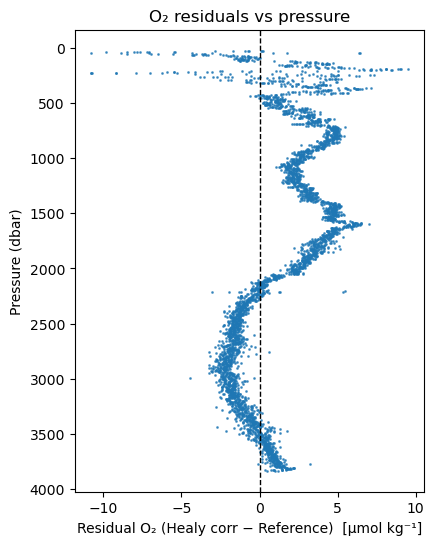

In [82]:
import numpy as np
import matplotlib.pyplot as plt
p_healy = station15['pressure'].to_numpy()
o2_healy_corr = station15['oxygen_exp'].to_numpy()
p_ref = winkler['pressure_wink'].to_numpy()
o2_ref = winkler['oxygen_wink'].to_numpy()
# your profile
p_y = np.asarray(p_healy, float)          # pressure (dbar)
o_y = np.asarray(o2_healy_corr, float)    # corrected O2 (µmol/kg)

# reference profile (Louis/St Laurent)
p_r = np.asarray(p_ref, float)
o_r = np.asarray(o2_ref, float)

# sort (interp requires increasing x)
iy = np.argsort(p_y); p_y, o_y = p_y[iy], o_y[iy]
ir = np.argsort(p_r); p_r, o_r = p_r[ir], o_r[ir]

# interpolate reference oxygen onto your pressure grid
o_r_on_y = np.interp(p_y, p_r, o_r, left=np.nan, right=np.nan)

# residuals (Healy - Reference)
res = o_y - o_r_on_y

# mask where interp is valid
m = np.isfinite(res)

plt.figure(figsize=(4.5,6))
plt.scatter(res[m], p_y[m], s=1, alpha=0.7)
plt.axvline(0, color="k", ls="--", lw=1)
plt.gca().invert_yaxis()
plt.xlabel("Residual O₂ (Healy corr − Reference)  [µmol kg⁻¹]")
plt.ylabel("Pressure (dbar)")
plt.title("O₂ residuals vs pressure")
plt.show()


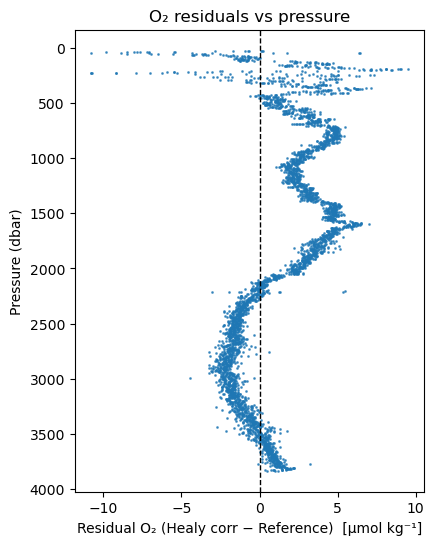

In [83]:
plt.figure(figsize=(4.5,6))
plt.scatter(res[m], p_y[m], s=1, alpha=0.7)
plt.axvline(0, color="k", ls="--", lw=1)
plt.gca().invert_yaxis()
plt.xlabel("Residual O₂ (Healy corr − Reference)  [µmol kg⁻¹]")
plt.ylabel("Pressure (dbar)")
plt.title("O₂ residuals vs pressure")
plt.show()


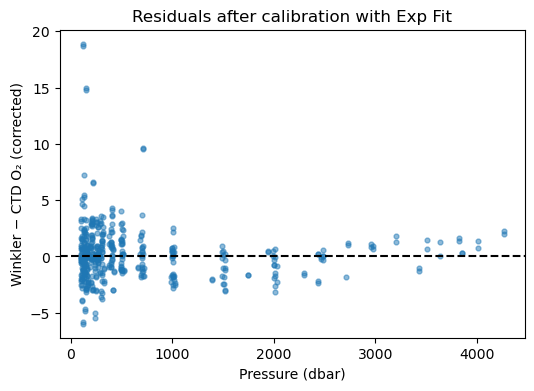

In [ ]:
exp_df["resid_winkler_corr"] = exp_df["oxygen_wink"] - exp_df["O2_correct_exp"]

plt.figure(figsize=(6,4))
plt.scatter(exp_df["pressure_ctd"], exp_df["resid_winkler_corr"], s=12, alpha=0.5)
plt.axhline(0, color="k", ls="--")
plt.xlabel("Pressure (dbar)")
plt.ylabel("Winkler − CTD O₂ (corrected)")
plt.
plt.title(f"Residuals after calibration with Exp Fit")
plt.show()



In [59]:
compare_atmax = compare.loc[compare[1] == 3832]
winkler_atmax = winkler.loc[winkler['pressure_wink'] == 3832.057]
station15_atmax = station15.loc[station15['pressure'] == 3832]

ax = station15.loc[station15['pressure'] == 3832]
winkler_atmax['oxygen_wink'].max(), compare_atmax['oxy'].max() , station15_atmax['oxygen_exp'].max(), station15_atmax['oxygen']

(280.8840851,
 278.01453624298074,
 282.72852110965044,
 7747    267.89
 Name: oxygen, dtype: float64)

In [18]:
bias = np.nanmean(res)
rmse = np.sqrt(np.nanmean(res**2))
sigma = np.nanstd(res)

print(f"Bias: {bias:.2f} µmol/kg")
print(f"RMSE: {rmse:.2f} µmol/kg")
print(f"Std:  {sigma:.2f} µmol/kg")


Bias: 2.15 µmol/kg
RMSE: 3.72 µmol/kg
Std:  3.03 µmol/kg
